In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(x_train.shape)

(50000, 32, 32, 3)


In [ ]:
class_names = [
      "airplane", "automobile", "bird", "cat", "deer",
      "dog", "frog", "horse", "ship", "truck"
]


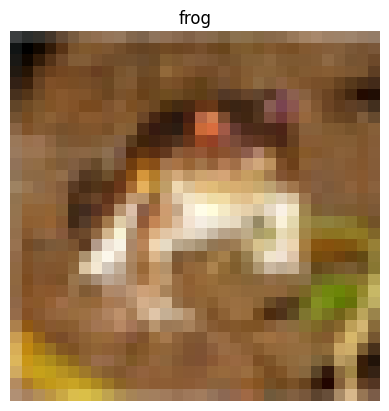

In [ ]:
plt.imshow(x_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis('off')
plt.show()

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
cnn = tf.keras.applications.MobileNetV2(
      input_shape=(32,32,3),
          include_top=False,
              weights=None,
                  pooling='avg'
)


In [ ]:
text_input = layers.Input(shape=(5,))
text_embedding = layers.Embedding(10, 32)(text_input)
lstm = layers.LSTM(64)(text_embedding)

In [ ]:
image_input = layers.Input(shape=(32,32,3))
image_features = cnn(image_input)

In [ ]:
combined = layers.Concatenate()([
      image_features,
          lstm
          ])

output = layers.Dense(10, activation='softmax')(combined)


In [ ]:
caption_model = Model(
      inputs=[image_input, text_input],
          outputs=output
)

caption_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 5, 32)     │        320 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_32 │ (None, 1280)      │  2,257,984 │ input_layer_2[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     24,832 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1344)      │          0 │ mobilenetv2_1.00… │
│ (Concatenate)       │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │     13,450 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,296,586 (8.76 MB)

 Trainable params: 2,262,474 (8.63 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
caption_model.compile(
      optimizer='adam',
          loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )


In [ ]:
text_data = np.zeros((len(x_train), 5))

print(text_data.shape)

(50000, 5)


In [ ]:
caption_model.fit(
      [x_train, text_data],
       y_train,
       epochs=2,
       batch_size=64
)


Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 313s 354ms/step - accuracy: 0.3026 - loss: 1.9113
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 272s 348ms/step - accuracy: 0.4236 - loss: 1.5878


In [ ]:
prediction = caption_model.predict(
      [x_test[:1], np.zeros((1,5))]
      )

print("Predicted caption:", class_names[prediction.argmax()])
print("Actual caption:", class_names[y_test[0][0]])


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted caption: cat
Actual caption: cat
